# Desk synthesis — Microstructure Noise / TSRV

Romero (2016) / ZMA05 TSRV on crypto perps (**HL · Deribit · Kraken**).

**Program status (Pass 2.8):** Pass 2.7 board **0 Promote / 5 Hold / 4 Kill** · predictive **0 Promote** after encompassing · n_ok=**204** · pairs=**180**

Hard rule: sized claims only if a **Promote** clears the pre-registered gate. Holds are monitors / research debt — not soft-Promotes.

**SoT:** [`DESK_MEMO.md`](../DESK_MEMO.md) · [`CHAPTER_INDEX.md`](../CHAPTER_INDEX.md) · [`TRADING_APPLICATIONS.md`](../TRADING_APPLICATIONS.md)  
**Also:** [`uses_and_information.ipynb`](uses_and_information.ipynb) · [`predictive_power.ipynb`](predictive_power.ipynb)


## 0. Setup — load Pass 2.7/2.8 artifacts (no multi-hour recompute)


In [1]:
from pathlib import Path
import os
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = (Path(os.environ.get('ARES_MICROSTRUCTURE') or (Path.home() / 'srv' / 'ares-microstructure')) / 'research' / 'books' / 'mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # ares-microstructure root

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
ep = jload('expand_panel/expand_panel.json')
dp = jload('depth_predict/depth_predict.json') if (OUT/'depth_predict'/'depth_predict.json').exists() else {}
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))
print('expand n_ok', ep['coverage']['n_ok'], 'depth keys', list(dp.keys())[:8])


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_info_heatmap.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_acf_lag1.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_pred_board.png', 'fig_pred_ic_noise.png', 'fig_ratio_hist.png', 'fig_signature.png', 'fig_tob_coverage.png', 'fig_tod_acf.png', 'fig_tsrv_oos.png', 'fig_venue_mid_taxonomy.png', 'signal_board.png']
expand n_ok 204 depth keys ['meta', 'information', 'predictive', 'taxonomy', 'tape_depth', 'uses', 'figures', 'decisions_rollup']


## 1. Signal board


**Signal board** — `out/desk_synthesis/figs/signal_board.png`

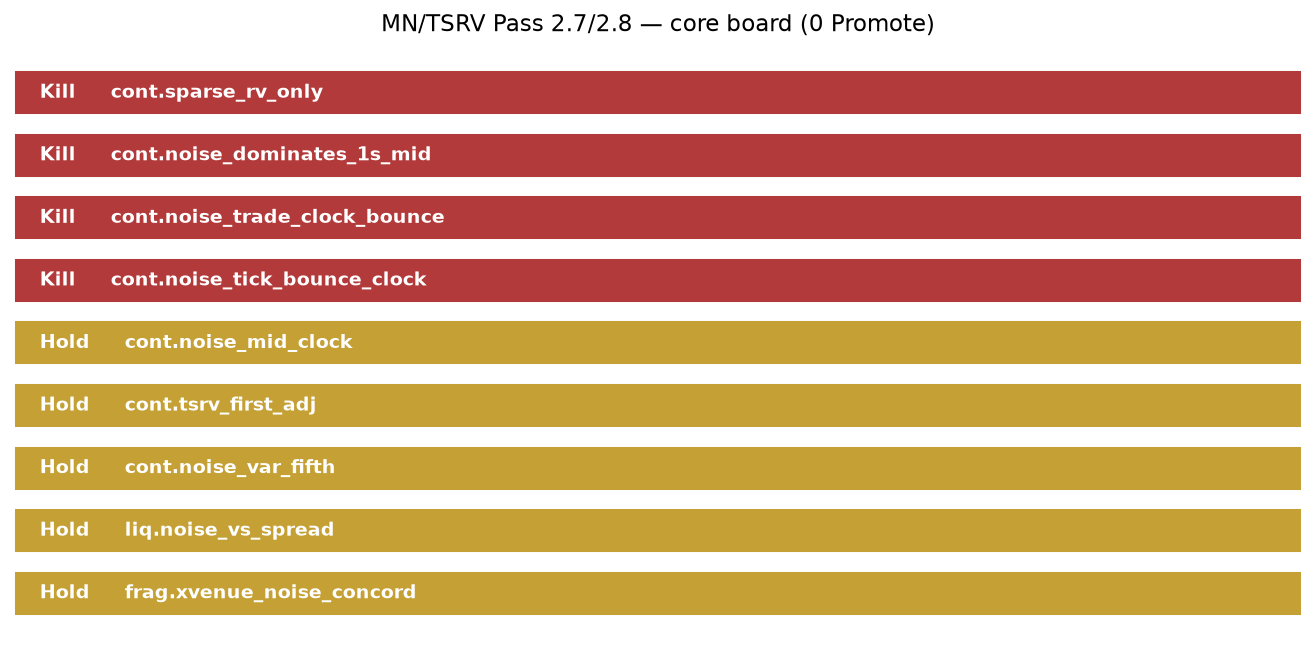

**Gate counts** — `out/desk_synthesis/figs/fig_gate_counts.png`

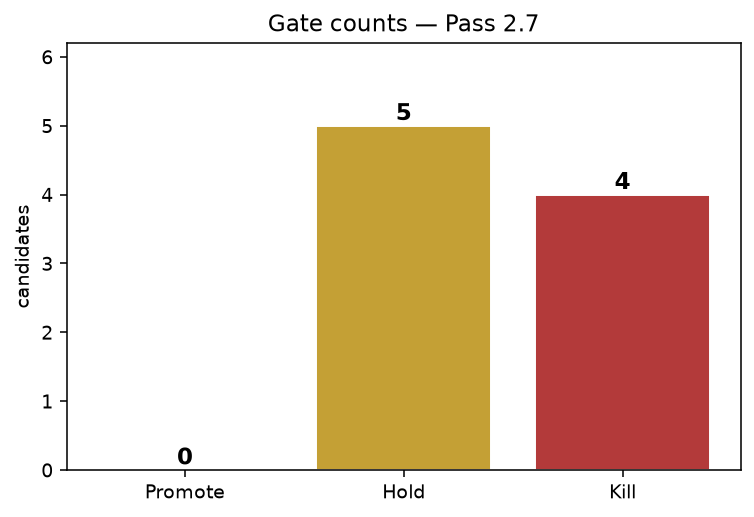

**Predictive board (Pass 2.8)** — `out/desk_synthesis/figs/fig_pred_board.png`

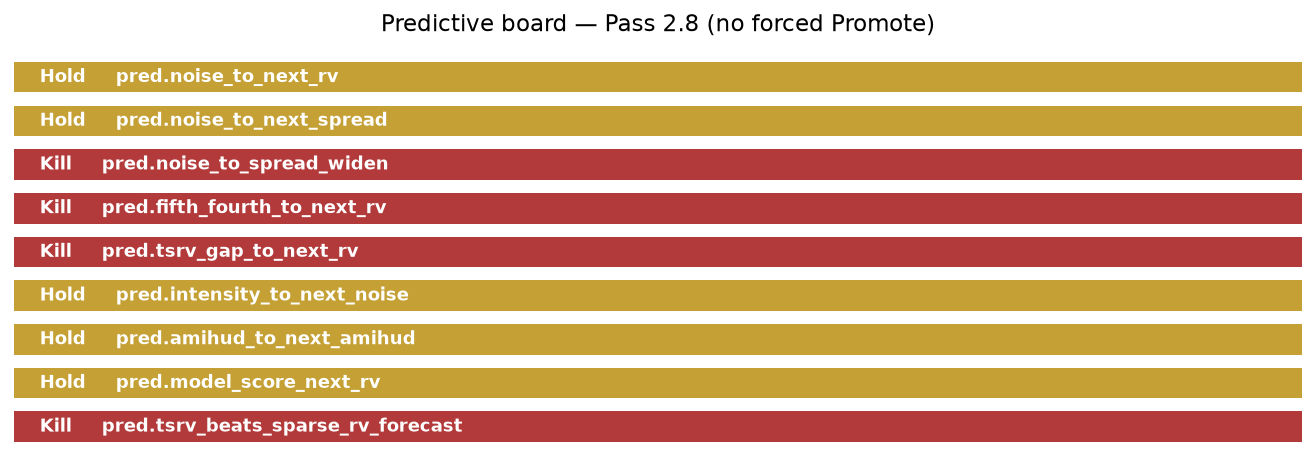

,id,decision,evidence
0,cont.sparse_rv_only,Kill,MC first_adj RMSE ≈ 0.42× fourth
1,cont.noise_dominates_1s_mid,Kill,calendar fifth/fourth med ≪ 1.5
2,cont.noise_trade_clock_bounce,Kill,trade-clock med ≪ 1.5
3,cont.noise_tick_bounce_clock,Kill,CI_lo ≰ 1.5
4,cont.noise_mid_clock,Hold,"dense mid median=2.449 CI=[1.130,3.777] SE=0.6..."
5,cont.tsrv_first_adj,Hold,fragile_rate=0.015 adv_med=5.58e-07 CI=[-5.949...
6,cont.noise_var_fifth,Hold,liquidity proxy only
7,liq.noise_vs_spread,Hold,"ρ=0.016 CI=[-0.169,0.168] shuffle_p=0.8375 blo..."
8,frag.xvenue_noise_concord,Hold,level concordance ≠ edge


,id,decision,evidence
0,pred.noise_to_next_rv,Hold,Raw OOS IC clears gate but encompassing fails:...
1,pred.noise_to_next_spread,Hold,OOS late same-sign but gate incomplete: late ρ...
2,pred.noise_to_spread_widen,Kill,"OOS late IC CI through 0: ρ=0.038 CI=[-0.218,0..."
3,pred.fifth_fourth_to_next_rv,Kill,"OOS late IC CI through 0: ρ=-0.091 CI=[-0.312,..."
4,pred.tsrv_gap_to_next_rv,Kill,"OOS late IC CI through 0: ρ=-0.152 CI=[-0.368,..."
5,pred.intensity_to_next_noise,Hold,OOS late same-sign but gate incomplete: late ρ...
6,pred.amihud_to_next_amihud,Hold,Amihud persistence clears IC gate but is liqui...
7,pred.model_score_next_rv,Hold,OOS late same-sign but gate incomplete: late ρ...
8,pred.tsrv_beats_sparse_rv_forecast,Kill,DM late prefer=sparse t=-1.997244766311049 n=94.0


Pass2.7 counts: {'Hold': 5, 'Kill': 4}


In [2]:
show_fig('signal_board.png', 'Signal board')
show_fig('fig_gate_counts.png', 'Gate counts')
show_fig('fig_pred_board.png', 'Predictive board (Pass 2.8)')

board = [
    ('cont.sparse_rv_only', 'Kill', 'MC first_adj RMSE ≈ 0.42× fourth'),
    ('cont.noise_dominates_1s_mid', 'Kill', 'calendar fifth/fourth med ≪ 1.5'),
    ('cont.noise_trade_clock_bounce', 'Kill', 'trade-clock med ≪ 1.5'),
    ('cont.noise_tick_bounce_clock', 'Kill', 'CI_lo ≰ 1.5'),
    ('cont.noise_mid_clock', 'Hold', ep['mid_clock']['gate']['why']),
    ('cont.tsrv_first_adj', 'Hold', ep['tsrv_oos']['gate']['why'][:160] + '…'),
    ('cont.noise_var_fifth', 'Hold', 'liquidity proxy only'),
    ('liq.noise_vs_spread', 'Hold', ep['spread_falsify']['gate']['why']),
    ('frag.xvenue_noise_concord', 'Hold', 'level concordance ≠ edge'),
]
df = pd.DataFrame(board, columns=['id', 'decision', 'evidence'])
display(df)
if dp:
    pred = pd.DataFrame([
        {'id': k, 'decision': v['decision'], 'evidence': v['why'][:120]}
        for k, v in dp.get('decisions_rollup', dp.get('predictive', {}).get('decisions', {})).items()
    ])
    display(pred)
print('Pass2.7 counts:', df.decision.value_counts().to_dict())


## 2. Pre-registered gates (do not move posts)

| ID | Promote only if |
|----|-----------------|
| `cont.noise_mid_clock` | bootstrap CI_lo of median fifth/fourth **> 1.5** |
| `cont.tsrv_first_adj` | fragile_rate=0 ∧ sparse−tsrv CI_lo>0 early **and** late ∧ n≥20 (**not** MC alone) |
| `liq.noise_vs_spread` | ρ>0 ∧ shuffle p<0.05 ∧ early∧late same sign ∧ n≥20 ∧ CI_lo>0 |
| `pred.*` | late OOS \|CI_lo\|>0.10 ∧ early same-sign; noise→RV also needs encompassing |
| `cont.sparse_rv_only` | already **Kill** on MC |


## 3. Monte Carlo — Kill sparse RV policy


**Heston MC RMSE ladder** — `out/desk_synthesis/figs/fig_mc_rmse_ladder.png`

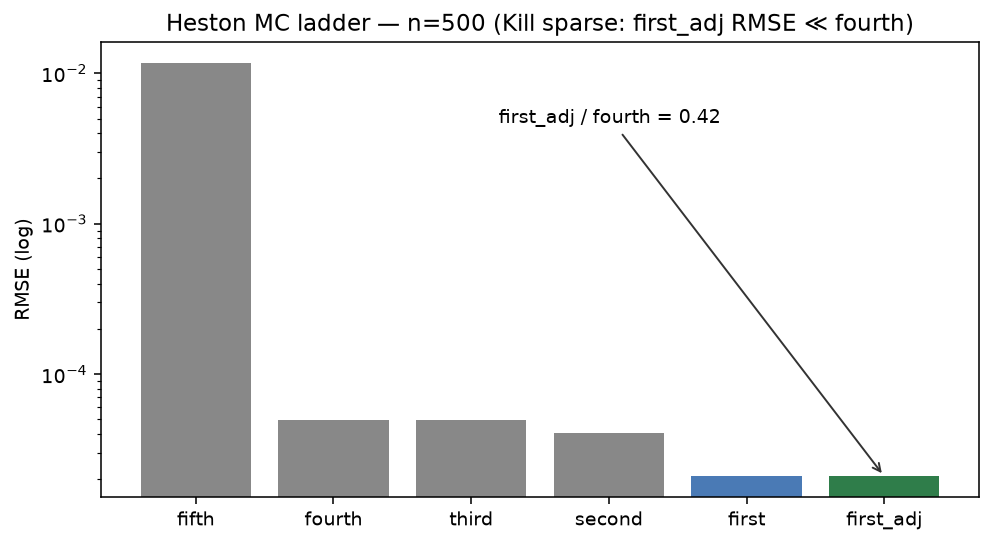

,estimator,bias,rmse,n
0,fifth,0.011695,0.011696,500
1,fourth,0.000038,0.000050,500
2,third,0.000038,0.000050,500
3,second,0.000035,0.000041,500
4,first,-0.000004,0.000021,500
5,first_adj,-0.000003,0.000021,500


first_adj / fourth RMSE = 0.419  -> Kill cont.sparse_rv_only (MC n=500)


In [3]:
show_fig('fig_mc_rmse_ladder.png', 'Heston MC RMSE ladder')
est = mc['estimators']
rows = []
for k in ['fifth','fourth','third','second','first','first_adj']:
    e = est[k]
    rows.append({'estimator': k, 'bias': e['bias'], 'rmse': e['rmse'], 'n': e['n']})
display(pd.DataFrame(rows))
ratio = est['first_adj']['rmse'] / est['fourth']['rmse']
print(f"first_adj / fourth RMSE = {ratio:.3f}  -> Kill cont.sparse_rv_only (MC n={mc['n_sims']})")


## 4. Mid-clock — Pass 2.7 expand, still **Hold**


**Clock medians ± CI95** — `out/desk_synthesis/figs/fig_clock_medians.png`

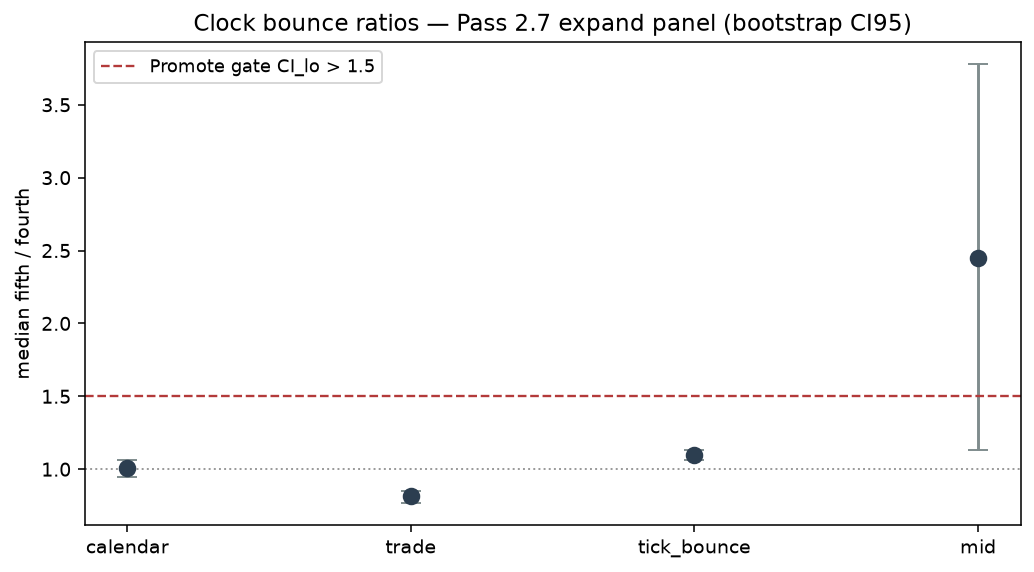

**Venue split** — `out/desk_synthesis/figs/fig_mid_venue_split.png`

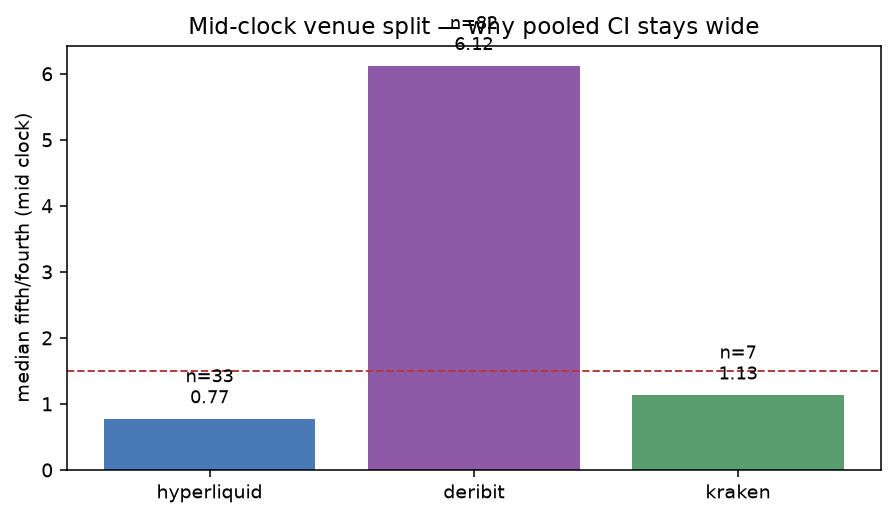

**Venue mid taxonomy (2.8)** — `out/desk_synthesis/figs/fig_venue_mid_taxonomy.png`

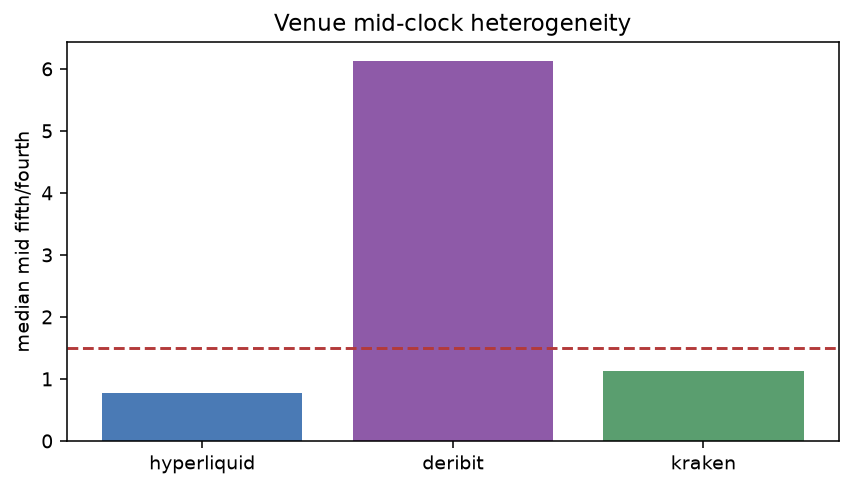

dense mid CI: {'n': 122.0, 'median': 2.4491608334091186, 'mean': 8.607163570387224, 'se': 0.6930382906851165, 'ci95': [1.1304373276015782, 3.7767079464514177]}
gate: {'id': 'cont.noise_mid_clock', 'decision': 'Hold', 'why': 'dense mid median=2.449 CI=[1.130,3.777] SE=0.693 n=122.0 (need CI_lo>1.5)'}
coverage: {
  "hyperliquid": {
    "n_mid": 33,
    "sources": [
      "collector",
      "warehouse:l2_rebuild"
    ],
    "median": 0.7705588921006542
  },
  "deribit": {
    "n_mid": 82,
    "sources": [
      "warehouse:l2_snapshot_level"
    ],
    "median": 6.118723615872716
  },
  "kraken": {
    "n_mid": 7,
    "sources": [
      "warehouse:kraken_spot_l2_rebuild"
    ],
    "median": 1.1304373276015782
  }
}


In [4]:
show_fig('fig_clock_medians.png', 'Clock medians ± CI95')
show_fig('fig_mid_venue_split.png', 'Venue split')
show_fig('fig_venue_mid_taxonomy.png', 'Venue mid taxonomy (2.8)')
md_ci = ep['mid_clock']['mid_dense_ci']
print('dense mid CI:', md_ci)
print('gate:', ep['mid_clock']['gate'])
print('coverage:', json.dumps(ep['mid_clock']['mid_coverage_by_venue'], indent=2))


## 5. Tape-level TSRV vs sparse — **Hold** (MC Kill stands)


**sparse − first_adj time-split** — `out/desk_synthesis/figs/fig_tsrv_oos.png`

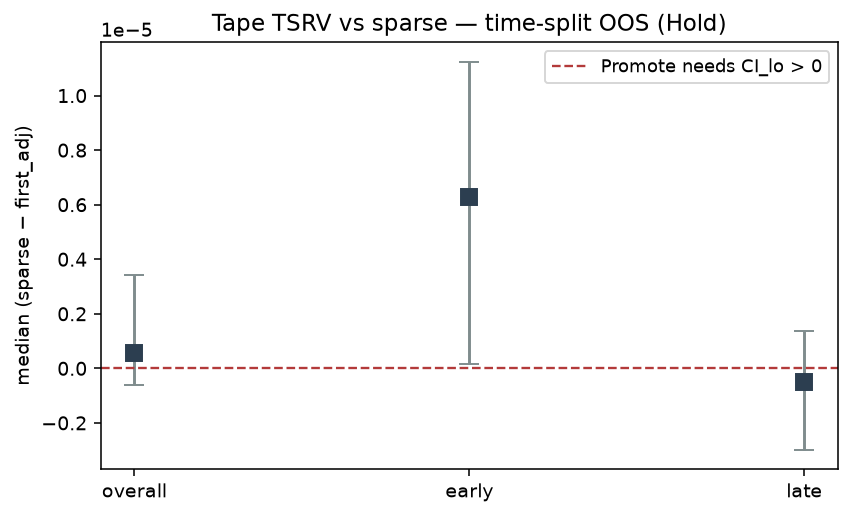

,n,median,mean,se,ci95
overall,204.0,0.000001,0.000003,0.000001,"[-5.949090895340435e-07, 3.4256954437953243e-06]"
early,101.0,0.000006,0.00002,0.000003,"[1.446921174782248e-07, 1.1235763937995365e-05]"
late,103.0,-0.0,-0.000013,0.000001,"[-2.9783714540724274e-06, 1.382499195019151e-06]"


fragile_rate 0.014705882352941176
decision: {'id': 'cont.tsrv_first_adj', 'decision': 'Hold', 'why': 'fragile_rate=0.015 adv_med=5.58e-07 CI=[-5.949090895340435e-07, 3.4256954437953243e-06] SE=9.82e-07 earlyCI=[1.446921174782248e-07, 1.1235763937995365e-05] lateCI=[-2.9783714540724274e-06, 1.382499195019151e-06] ratio_med=0.9844 ratioCI=[0.9628826697099598, 1.0109329144617558] roll_ci_lo_pos_frac=0.07 n=204 (MC Kill sparse still stands; Promote needs OOS CI_lo>0 early∧late)'}


In [5]:
show_fig('fig_tsrv_oos.png', 'sparse − first_adj time-split')
ts = ep['tsrv_oos']
display(pd.DataFrame(ts['sparse_minus_tsrv']).T)
print('fragile_rate', ts['fragile_rate'])
print('decision:', ts['gate'])


## 6. Noise vs spread + information content


**noise vs spread** — `out/desk_synthesis/figs/fig_noise_vs_spread.png`

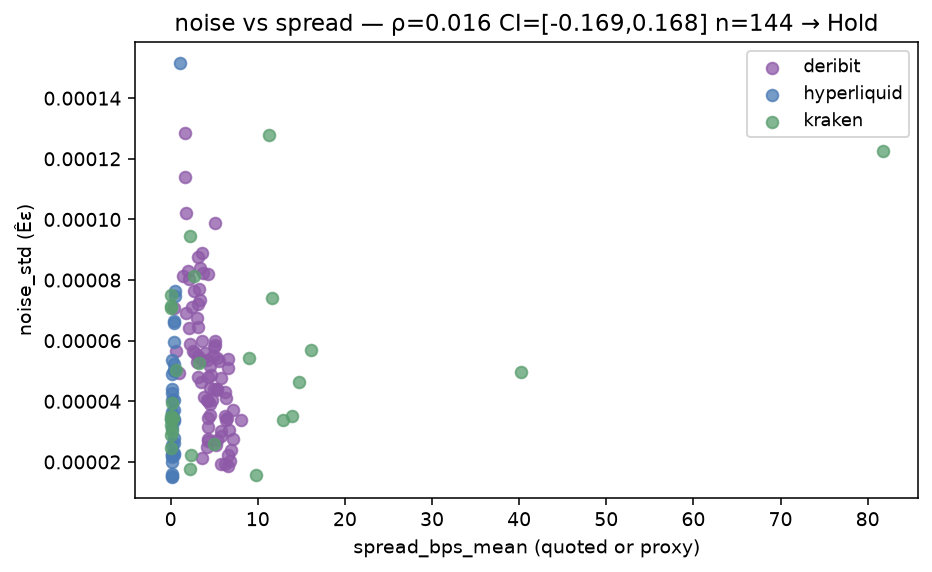

**Information heatmap** — `out/desk_synthesis/figs/fig_info_heatmap.png`

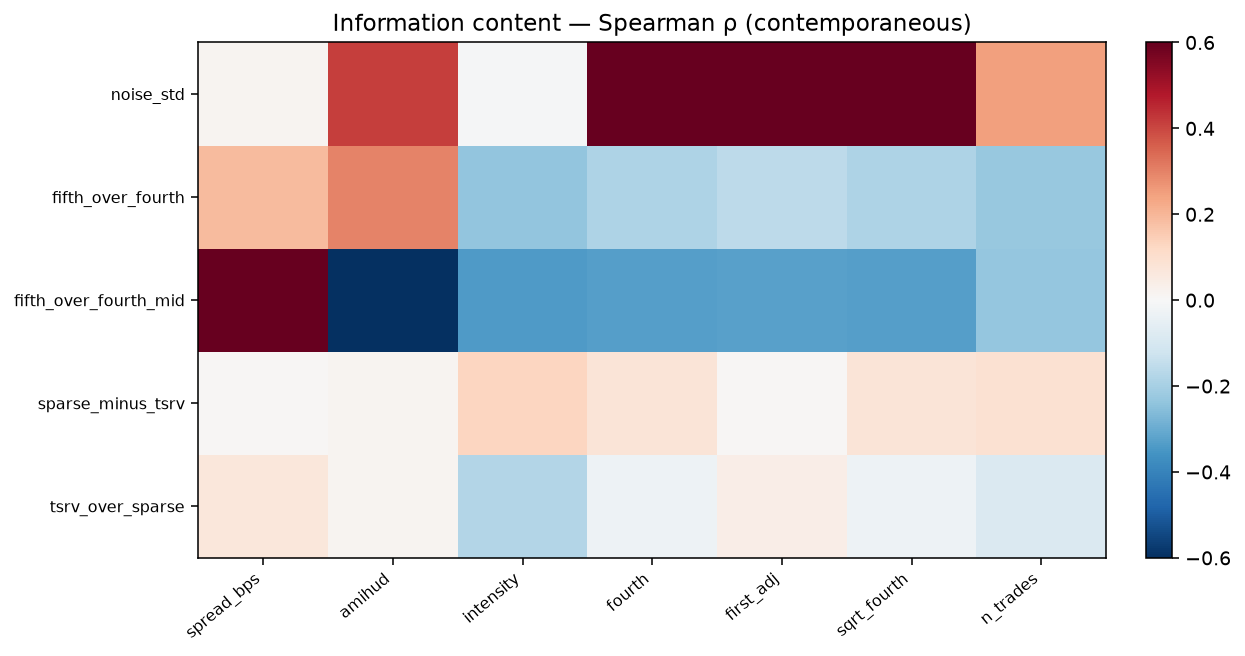

ρ_spread: {'n': 144.0, 'rho': 0.016405433646812958, 'lo': -0.1693348605417571, 'hi': 0.16769039868177793}
ρ_amihud: {'n': 144.0, 'rho': 0.3280564263322884, 'lo': -0.15052065750341612, 'hi': 0.16548378345792134}
gate: {'id': 'liq.noise_vs_spread', 'decision': 'Hold', 'why': 'ρ=0.016 CI=[-0.169,0.168] shuffle_p=0.8375 block_p=0.7462 n=144 same_sign=False ci_pos=False early_n=59.0 late_n=85.0'}


,n,rho,lo,hi,shuffle_p
spread_bps,144.0,0.016405,-0.163259,0.190791,0.8475
amihud,204.0,0.413934,0.312555,0.508768,0.0000
intensity,204.0,-0.008550,-0.127586,0.128315,0.9050
fourth,204.0,0.765013,0.691822,0.823472,0.0000
first_adj,204.0,0.764005,0.689614,0.824886,0.0000
sqrt_fourth,204.0,0.765013,0.691073,0.826359,0.0000
n_trades,204.0,0.246807,0.106533,0.366598,0.0000


In [6]:
show_fig('fig_noise_vs_spread.png', 'noise vs spread')
show_fig('fig_info_heatmap.png', 'Information heatmap')
sf = ep['spread_falsify']
print('ρ_spread:', sf['rho_spread'])
print('ρ_amihud:', sf['rho_amihud'])
print('gate:', sf['gate'])
if dp:
    ns = dp['information']['matrix']['noise_std']
    display(pd.DataFrame(ns).T)


## 7. Thesis empirics — signature / ACF / K


**Signature plots** — `out/desk_synthesis/figs/fig_signature.png`

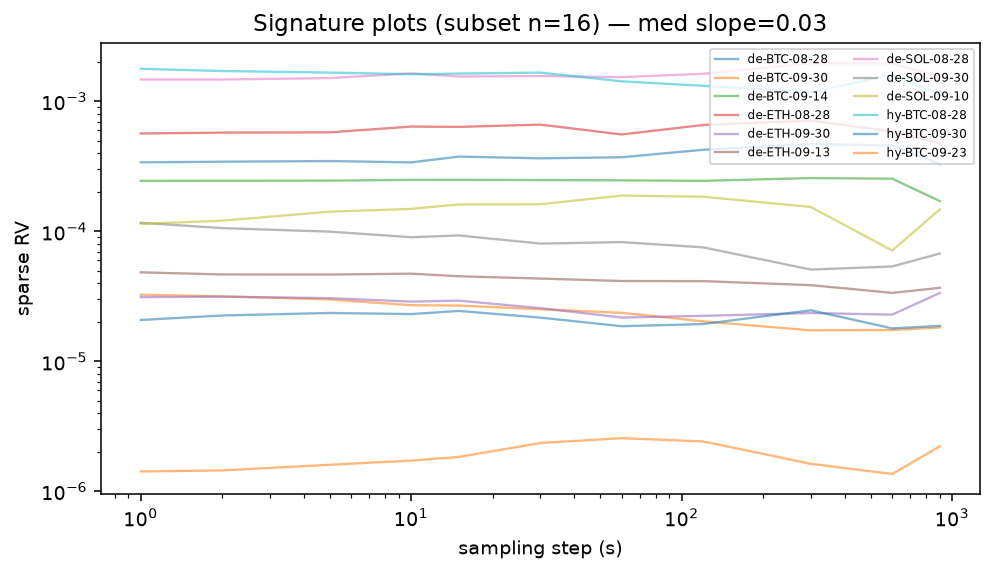

**ACF lag-1** — `out/desk_synthesis/figs/fig_noise_acf_lag1.png`

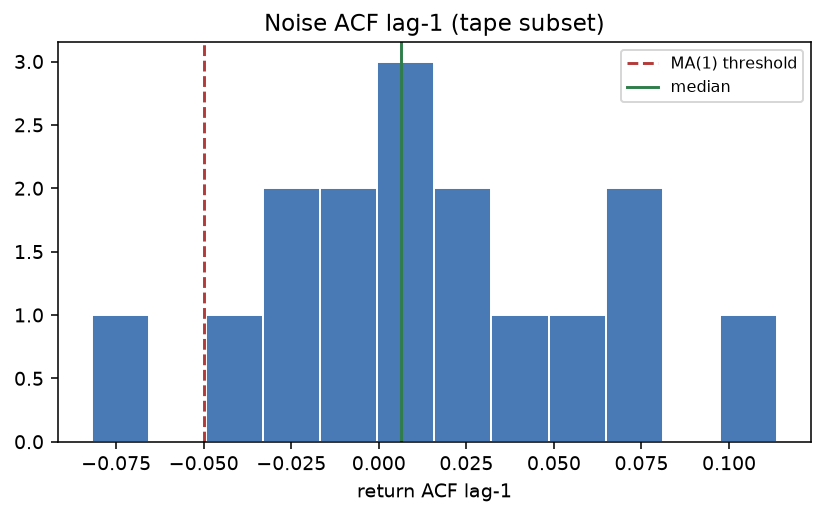

**TOD ACF** — `out/desk_synthesis/figs/fig_tod_acf.png`

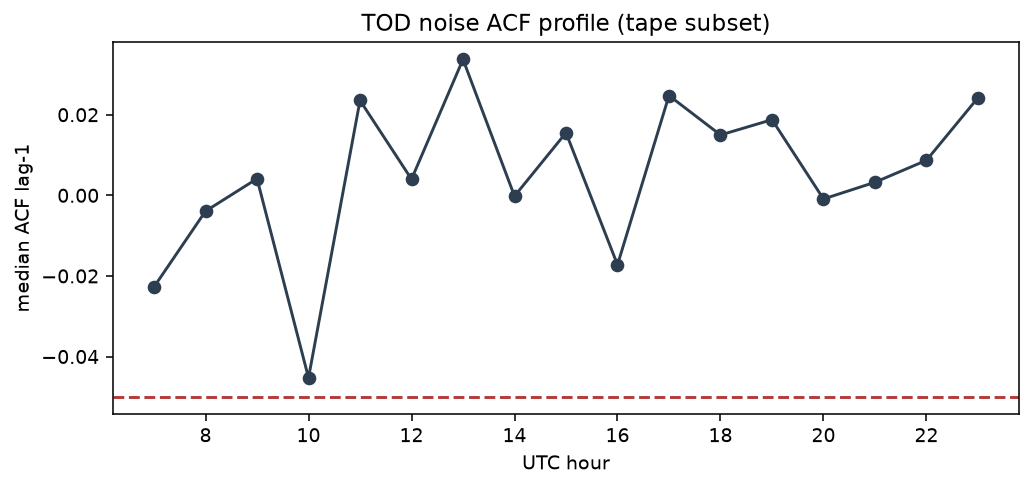

signature: 0.029292820592576027 frac_neg 0.3125
acf lag1: 0.006424349386435315 ma1_frac 0.0625
opt K: 180.0


In [7]:
show_fig('fig_signature.png', 'Signature plots')
show_fig('fig_noise_acf_lag1.png', 'ACF lag-1')
show_fig('fig_tod_acf.png', 'TOD ACF')
if dp:
    td = dp['tape_depth']
    print('signature:', td.get('signature', {}).get('median_fine_log_slope'), 'frac_neg', td.get('signature', {}).get('frac_negative_slope'))
    print('acf lag1:', td.get('noise_acf', {}).get('median_lag1'), 'ma1_frac', td.get('noise_acf', {}).get('frac_ma1_compatible'))
    print('opt K:', td.get('optimal_K', {}).get('median_best_K'))


## 8. Predictive OOS (see predictive_power notebook)


**noise_std OOS IC forest** — `out/desk_synthesis/figs/fig_pred_ic_noise.png`

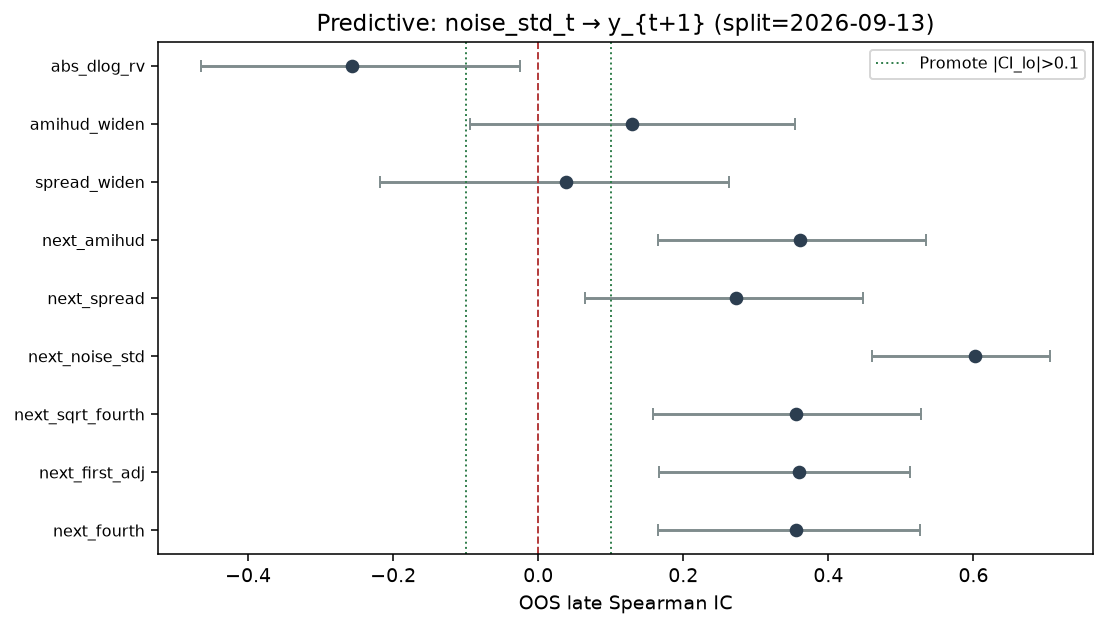

n_pairs 180 split 2026-09-13
encompassing {'early': {'n': 86.0, 'noise_partial_ic': -0.0031416576253596867, 'fourth_partial_ic': 0.2905514411057125, 'noise_raw_ic': 0.2772111892070381, 'fourth_raw_ic': 0.38615972451530733}, 'late_oos': {'n': 94.0, 'noise_partial_ic': 0.06461004948885597, 'fourth_partial_ic': 0.24766824404869414, 'noise_raw_ic': 0.35508434779467546, 'fourth_raw_ic': 0.4271430119567966}}
DM late {'n': 94.0, 'mean_d': -1.4462859025779148e-08, 't': -1.997244766311049, 'ci95': [-2.9367796424669494e-08, -6.277988094833541e-10], 'prefer': 'sparse', 'note': 'd=err_sparse_sq-err_tsrv_sq; >0 ⇒ err_sparse_sq worse'}


In [8]:
show_fig('fig_pred_ic_noise.png', 'noise_std OOS IC forest')
if dp:
    pred = dp['predictive']
    print('n_pairs', pred.get('n_pairs'), 'split', pred.get('split_day'))
    print('encompassing', pred.get('encompassing_noise_vs_sparse'))
    print('DM late', pred.get('diebold_mariano', {}).get('next_fourth_persistence', {}).get('late_oos'))


## 9. Kraken TOB inventory


**TOB coverage by venue** — `out/desk_synthesis/figs/fig_tob_coverage.png`

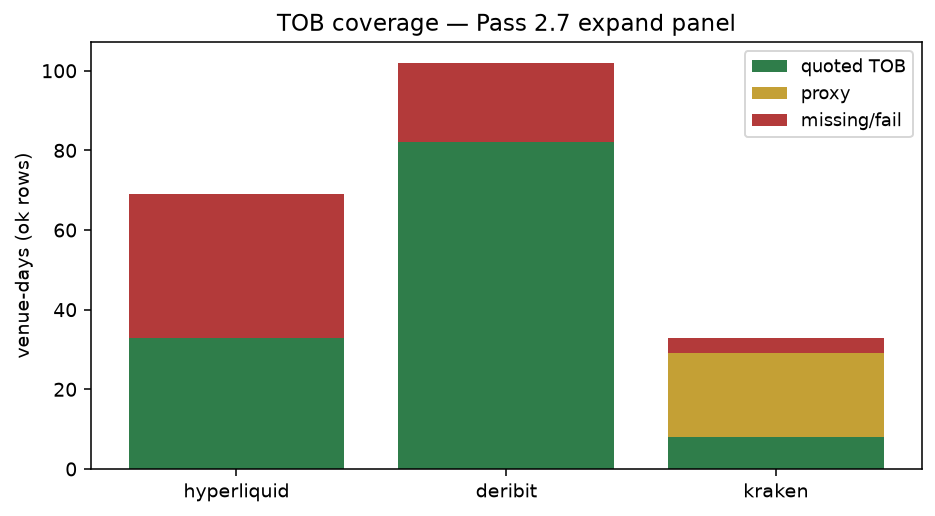

expand spread sources: {'None': 56, 'warehouse:l2_snapshot_level': 82, 'kraken_proxy': 25, 'warehouse:l2_rebuild': 29, 'warehouse:kraken_spot_l2_rebuild': 8, 'collector': 4}


In [9]:
show_fig('fig_tob_coverage.png', 'TOB coverage by venue')
from collections import Counter
srcs = Counter(str((r.get('spread') or {}).get('source')) for r in ep['rows'] if r.get('ok'))
print('expand spread sources:', dict(srcs))


## 10. Desk takeaway

1. **Do not** run sparse-only RV for risk — MC Kill is decisive.  
2. Mid-clock / tape TSRV / noise↔spread remain **Hold** (Pass 2.7).  
3. Predictive: noise→next RV raw IC looks real but is **encompassed by sparse RV persistence** → Hold.  
4. DM does **not** favor TSRV over sparse for next-day fourth persistence on late OOS.  
5. Uses: prefer TSRV for risk σ; mid-clock for quoting trust; no auto-widen on noise_std.

See [`uses_and_information.ipynb`](uses_and_information.ipynb) · [`predictive_power.ipynb`](predictive_power.ipynb).
